# Teste de Baseline com regressão linear para predição de resistência à compressão

In [186]:
%%capture
!pip install optuna

In [187]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [188]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [189]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear simples
simples_file = 'df_resistencia_RL.pkl'
simples_path = os.path.join(dirpath, simples_file)

df_simples = pd.read_pickle(simples_path)
df_simples['target'] = df_simples['Resistencia_Compressao_MPa'].copy()
df_simples.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Lasso
lasso_file = 'df_resistencia_Lasso.pkl'
lasso_path = os.path.join(dirpath, lasso_file)

df_lasso = pd.read_pickle(lasso_path)
df_lasso['target'] = df_lasso['Resistencia_Compressao_MPa'].copy()
df_lasso.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear Ridge
ridge_file = 'df_resistencia_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão linear ElasticNet
elasticnet_file = 'df_resistencia_ElasticNet.pkl'
elasticnet_path = os.path.join(dirpath, elasticnet_file)

df_elasticnet = pd.read_pickle(elasticnet_path)
df_elasticnet['target'] = df_elasticnet['Resistencia_Compressao_MPa'].copy()
df_elasticnet.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [190]:
df_simples.shape, df_lasso.shape, df_ridge.shape, df_elasticnet.shape

((466, 25), (466, 14), (531, 40), (466, 29))

## Teste com Regressão simples

In [191]:
n_groups = df_simples['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [192]:
all_preds = []
all_true = []
all_groups = []

X = df_simples.drop(
    columns=["target", "Autores/ano"]
)

y = df_simples["target"]
groups = df_simples["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [193]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

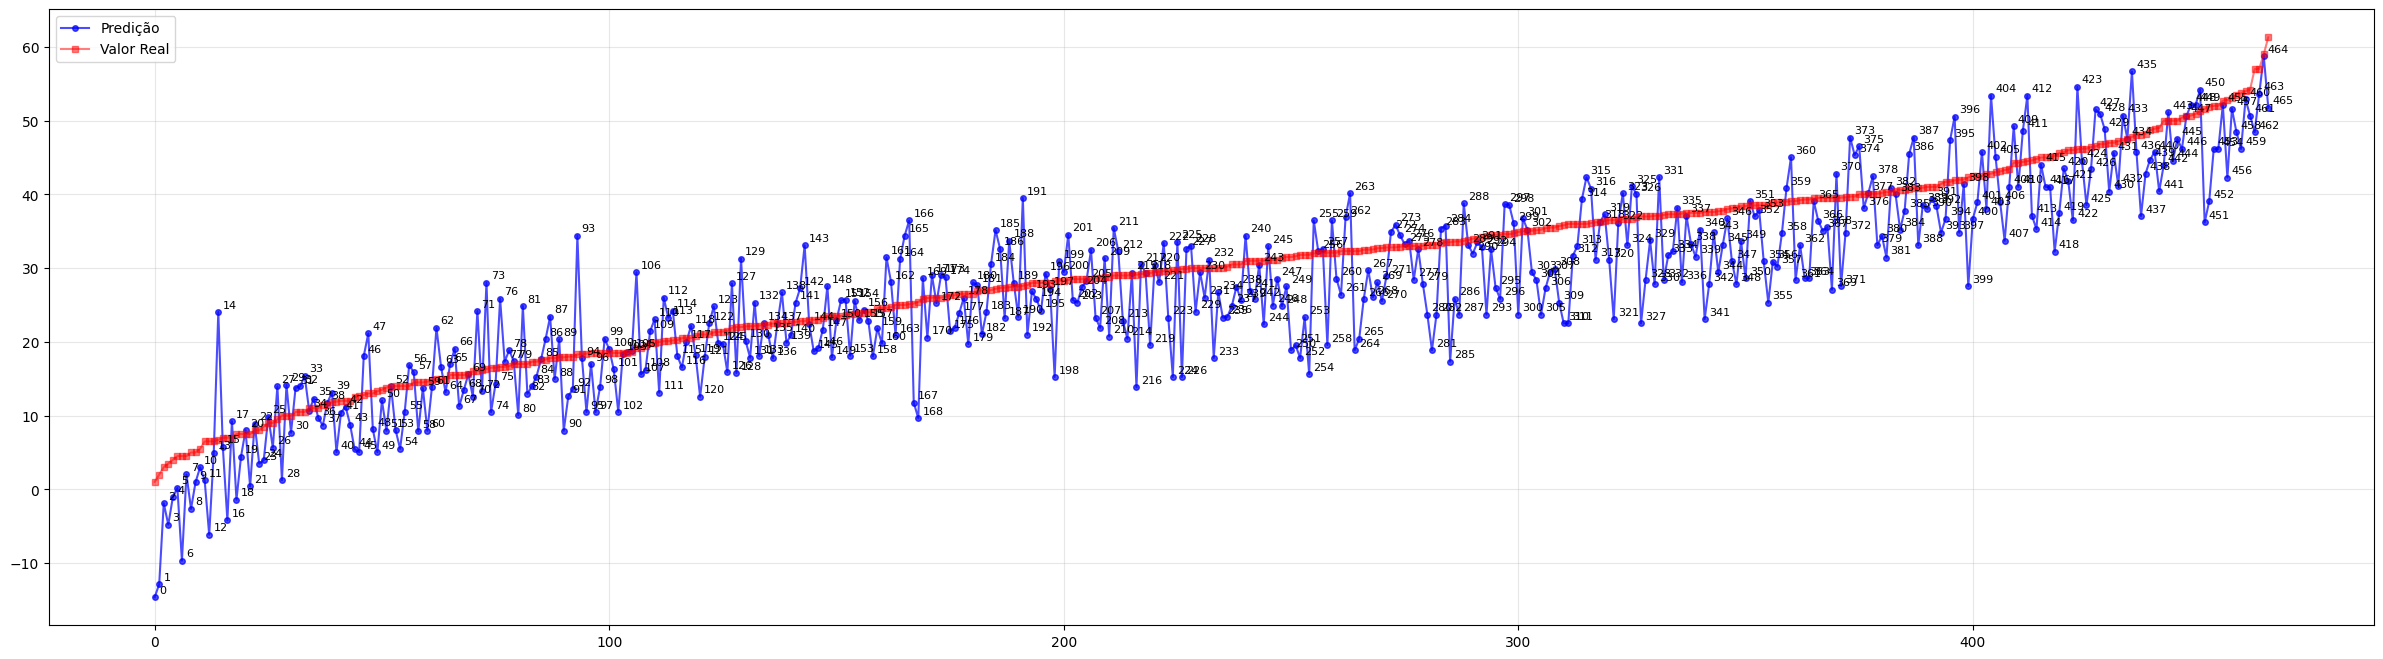

In [194]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

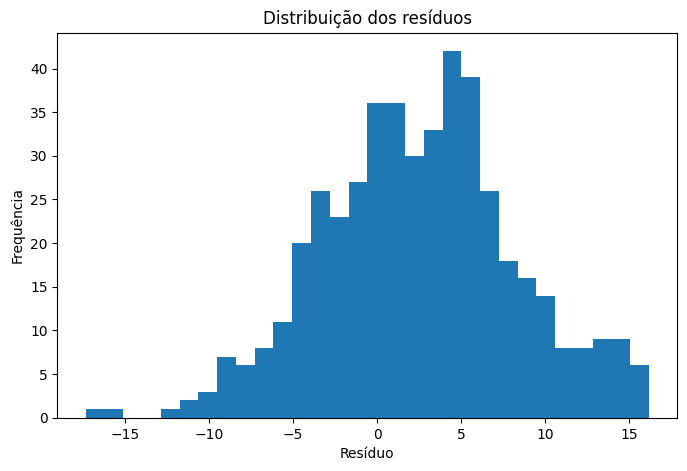

In [195]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

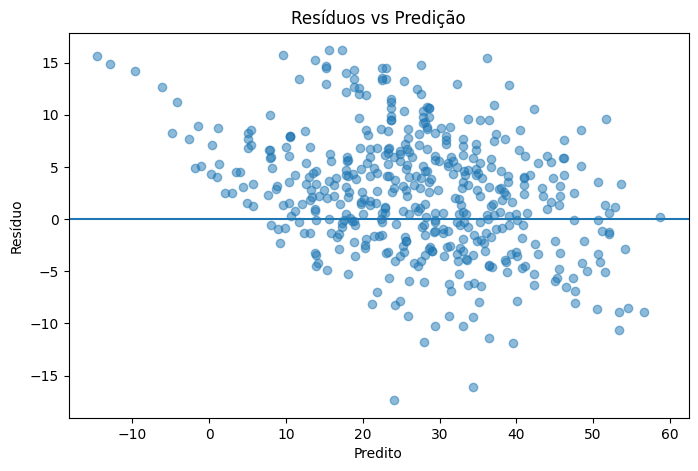

In [196]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

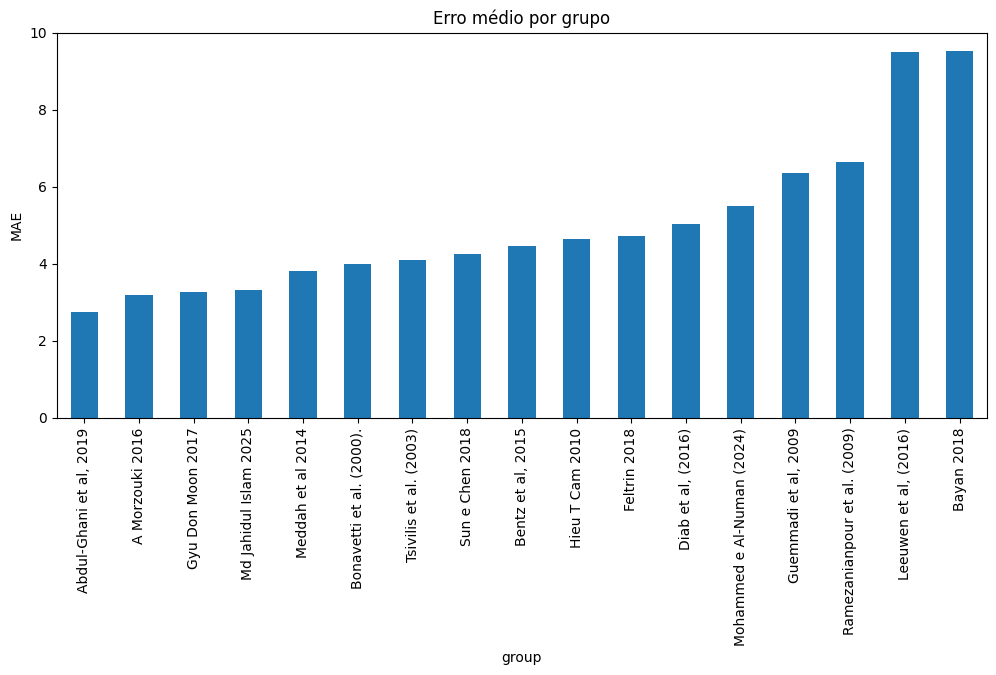

In [197]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [198]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 6.2807
mean_absolute_error: 5.0086
mean_absolute_percentage_error: 0.2687
R² Score: 73.3278


# Teste com regressão Lasso

In [199]:
X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 10)
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = Lasso(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [200]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Lasso")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_lasso = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_lasso.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_lasso.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_lasso.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Lasso:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-10 03:31:25,407] A new study created in memory with name: Tuning_Concreto
[I 2026-06-10 03:31:25,615] Trial 0 finished with value: 10.064758690689015 and parameters: {'alpha': 8.496549725135422}. Best is trial 0 with value: 10.064758690689015.
[I 2026-06-10 03:31:25,822] Trial 1 finished with value: 10.356018313333255 and parameters: {'alpha': 8.949885791149972}. Best is trial 0 with value: 10.064758690689015.
[I 2026-06-10 03:31:26,000] Trial 2 finished with value: 8.93860585863889 and parameters: {'alpha': 6.8036092858421915}. Best is trial 2 with value: 8.93860585863889.
[I 2026-06-10 03:31:26,197] Trial 3 finished with value: 8.520096927307366 and parameters: {'alpha': 6.26144376039924}. Best is trial 3 with value: 8.520096927307366.
[I 2026-06-10 03:31:26,392] Trial 4 finished with value: 5.926878558824888 and parameters: {'alpha': 2.124978455629548}. Best is trial 4 with value: 5.926878558824888.
[I 2026-06-10 03:31:26,574] Trial 5 finished with value: 10.5798168845061

Melhor RMSE alcançado (Cross-Validation): 4.8560
Melhores Hiperparâmetros encontrados:
  'alpha': 0.7523042622627596,


In [201]:
all_preds = []
all_true = []
all_groups = []

X = df_lasso.drop(
    columns=["target", "Autores/ano"]
)

y = df_lasso["target"]
groups = df_lasso["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Lasso(alpha=study_lasso.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [202]:
lasso_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lasso_results["residual"] = (
    lasso_results["y_true"] -
    lasso_results["y_pred"]
)

lasso_results["abs_error"] = (
    lasso_results["residual"].abs()
)

## Observado vs Predito

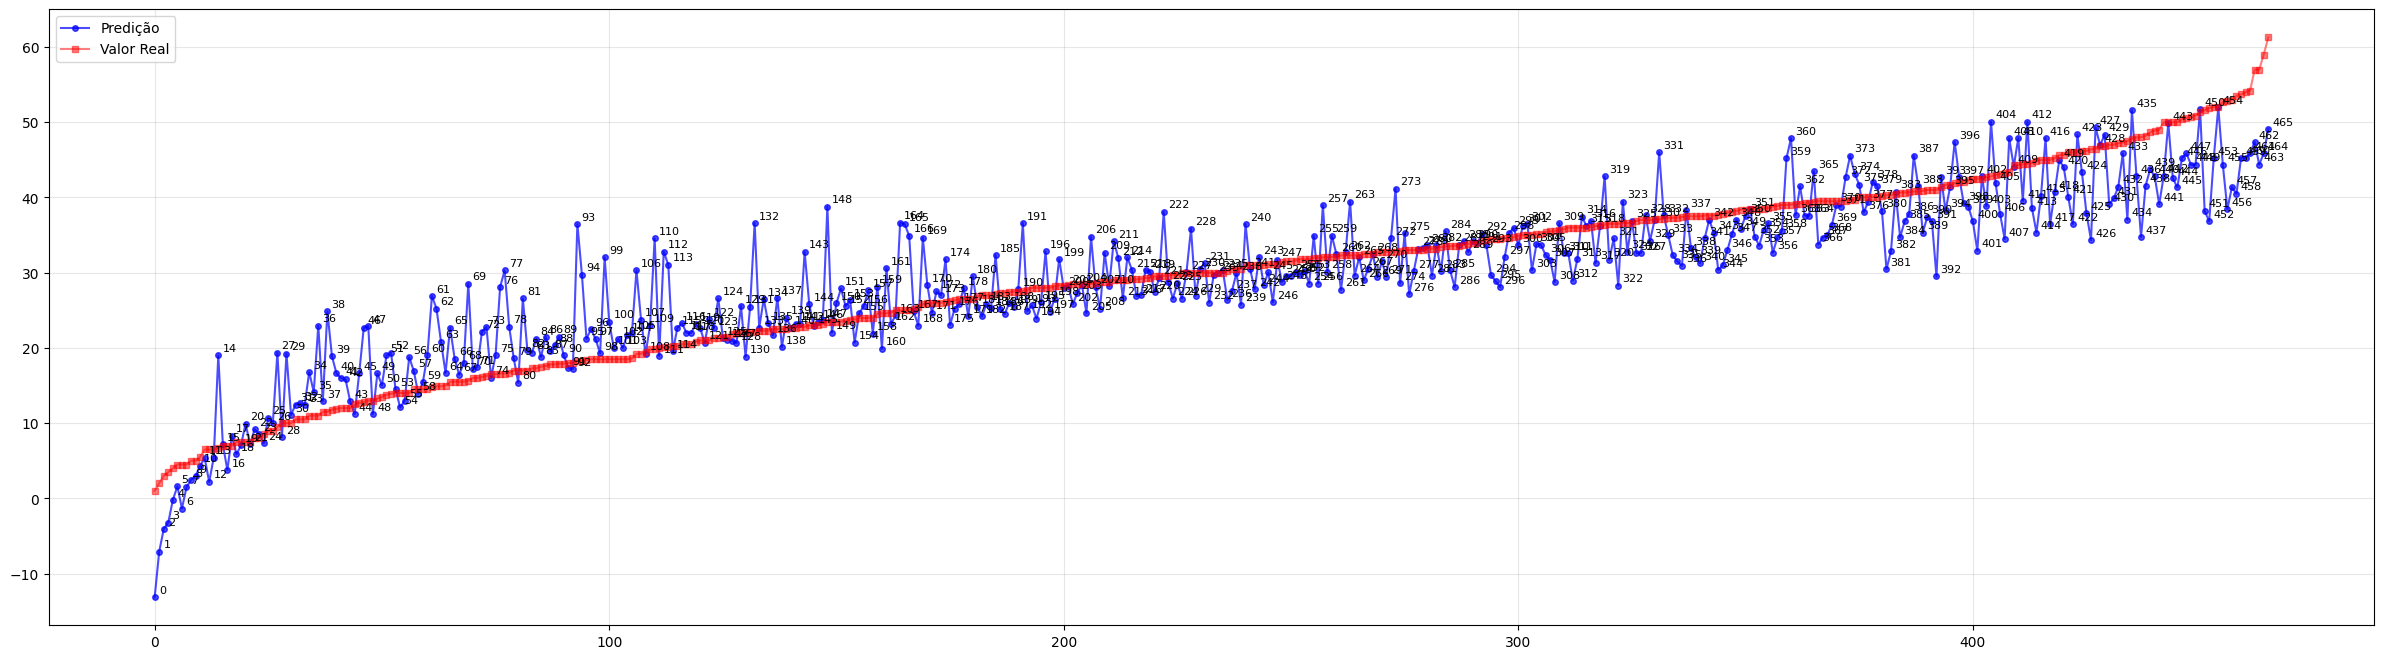

In [203]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lasso_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

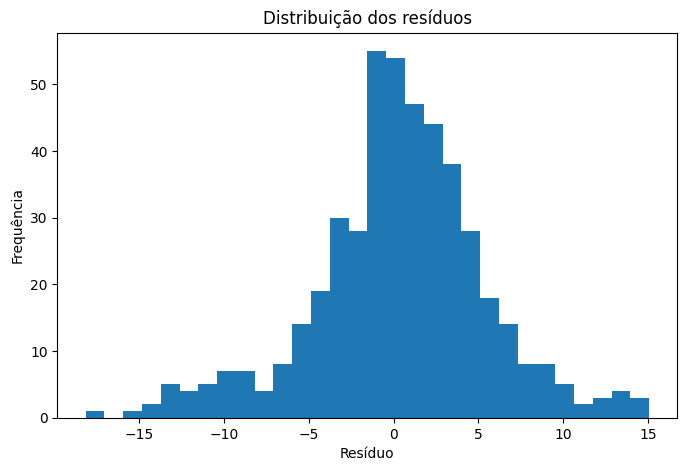

In [204]:
plt.figure(figsize=(8,5))

plt.hist(
    lasso_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

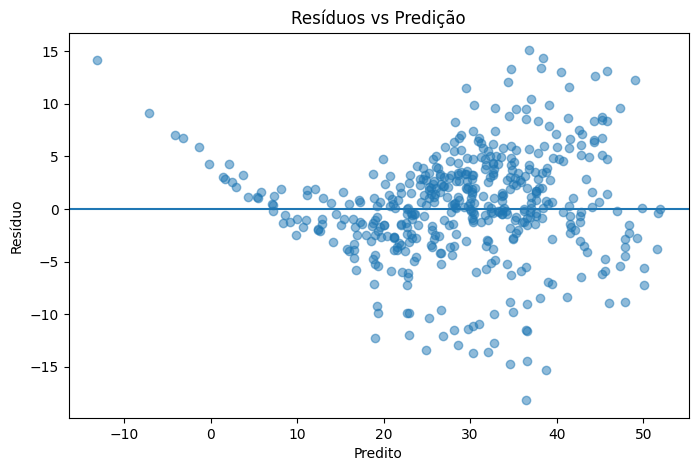

In [205]:
plt.figure(figsize=(8,5))

plt.scatter(
    lasso_results["y_pred"],
    lasso_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

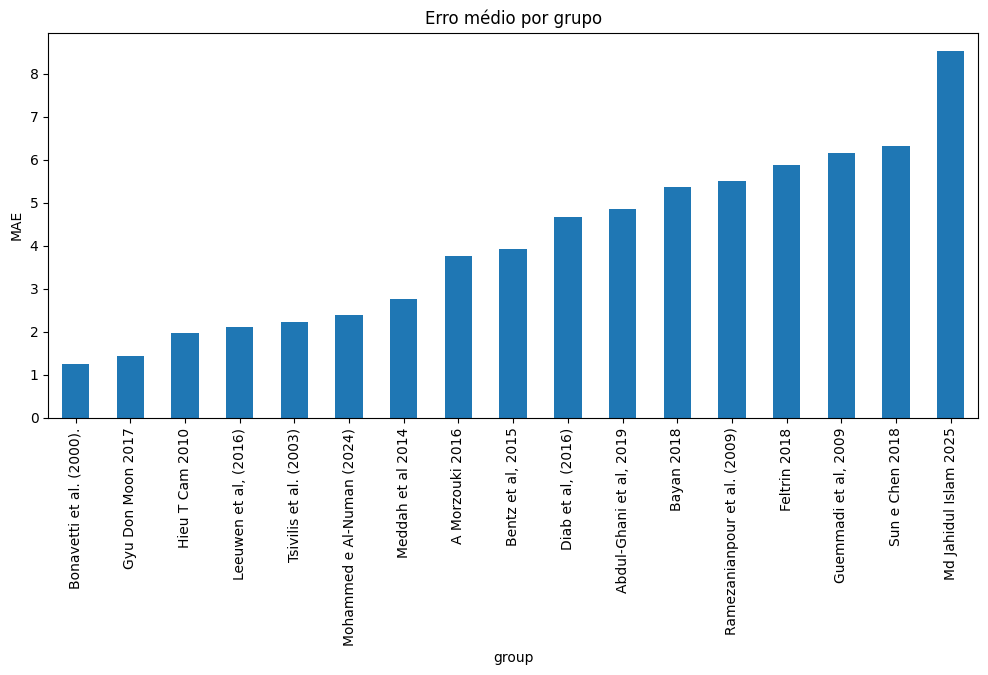

In [206]:
group_errors = (
    lasso_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [207]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.1484
mean_absolute_error: 3.8204
mean_absolute_percentage_error: 0.2068
R² Score: 82.0782


## Teste com regressão Ridge

In [211]:
n_groups = df_ridge['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 16


In [212]:
X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

def objective(trial):
    rmse_scores = []

    alpha = trial.suggest_float("alpha", 0.01, 1000)
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler_train = StandardScaler()

        X_train = scaler_train.fit_transform(X_train)
        X_val = scaler_train.transform(X_val)

        model = Ridge(alpha=alpha, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [213]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Regressão Ridge")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_ridge = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_ridge.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_ridge.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_ridge.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão Ridge:   0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-06-10 03:34:51,793] A new study created in memory with name: Tuning_Concreto
[I 2026-06-10 03:34:52,037] Trial 0 finished with value: 5.904658762784761 and parameters: {'alpha': 6.634542296164021}. Best is trial 0 with value: 5.904658762784761.
[I 2026-06-10 03:34:52,333] Trial 1 finished with value: 6.754322325882468 and parameters: {'alpha': 419.0576054660594}. Best is trial 0 with value: 5.904658762784761.
[I 2026-06-10 03:34:52,782] Trial 2 finished with value: 6.989331834987204 and parameters: {'alpha': 720.4091606428583}. Best is trial 0 with value: 5.904658762784761.
[I 2026-06-10 03:34:53,232] Trial 3 finished with value: 6.64345365695868 and parameters: {'alpha': 265.719860213394}. Best is trial 0 with value: 5.904658762784761.
[I 2026-06-10 03:34:53,697] Trial 4 finished with value: 6.6661708246033715 and parameters: {'alpha': 298.0353982084627}. Best is trial 0 with value: 5.904658762784761.
[I 2026-06-10 03:34:54,673] Trial 5 finished with value: 6.964021264411123 a

Melhor RMSE alcançado (Cross-Validation): 5.3963
Melhores Hiperparâmetros encontrados:
  'alpha': 1.6069846551439326,


In [214]:
all_instances = []

X = df_ridge.drop(
    columns=["target", "Autores/ano"]
)

y = df_ridge["target"]
groups = df_ridge["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = Ridge(alpha=study_ridge.best_params["alpha"], random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    fold_results = df_ridge.iloc[val_idx].copy()

    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = (
        fold_results["y_true"] - fold_results["y_pred"]
    )
    fold_results["abs_error"] = (
        fold_results["error"].abs()
    )
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

In [215]:
X.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Usa_SP', 'D_Max', 'cod_classe',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3', 'vol_brita',
       'porosidade_volumetrica_inicial', 'vol_po_total', 'pasta_agregado',
       'aglomerante_total', 'finos_total', 'range_granulometrico',
       'parametro_feret', 'saturacao_pasta', 'qualidade_adensamento',
       'fator_resistencia_rocha', 'parametro_feret_filer_k5',
       'idade_parametro_feret_filer_k5', 'pow_cubo_vol', 'razao_powers_feret',
       'ryshkewitch_real', 'ryshkewitch_linearizado',
       'hasselman_fator_inicial', 'hasselman_fator_real', 'hasselman_cinetico',
       'schiller_real', 'aci_209_fator_tempo', 's_fib', 'pasta_agregado_fino',
       'densidade_matriz', 'vol_cimento', 'vol_filer',
       'Relacao_Agua_Aglomerante', 'vol_sp'],
      dtype='object')

In [216]:
coef = pd.Series(
    model.coef_,
    index=X.columns
).sort_values(key=np.abs, ascending=False)

print(coef.head(20))

idade_parametro_feret_filer_k5    6.739377
pasta_agregado_fino               5.420188
parametro_feret                   5.375803
finos_total                      -4.708500
saturacao_pasta                  -4.329379
pasta_agregado                   -4.329379
pow_cubo_vol                      4.183744
Relacao_Agua_Aglomerante         -4.033633
densidade_matriz                  3.730696
s_fib                            -3.205417
Massa_Esp_Cimento_kg_m3          -2.786046
Cimento_kg_m3                    -2.729601
vol_cimento                      -2.583075
hasselman_fator_inicial          -2.471765
porosidade_volumetrica_inicial    2.471765
ryshkewitch_linearizado          -2.471765
Filer_Calcario_kg_m3              2.310451
aci_209_fator_tempo               1.999265
Finura_Cimento_Blaine_m2_kg       1.959611
schiller_real                     1.861318
dtype: float64


In [217]:
all_instances[0].columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Usa_SP', 'D_Max', 'cod_classe',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3', 'vol_brita',
       'porosidade_volumetrica_inicial', 'vol_po_total', 'pasta_agregado',
       'aglomerante_total', 'finos_total', 'range_granulometrico',
       'parametro_feret', 'saturacao_pasta', 'qualidade_adensamento',
       'fator_resistencia_rocha', 'parametro_feret_filer_k5',
       'idade_parametro_feret_filer_k5', 'pow_cubo_vol', 'razao_powers_feret',
       'ryshkewitch_real', 'ryshkewitch_linearizado',
       'hasselman_fator_inicial', 'hasselman_fator_real', 'hasselman_cinetico',
       'schiller_real', 'aci_209_fator_tempo', 's_fib', 'pasta_agregado_fino',
       'densidade_matriz', 'Autores/ano', 'vol_cimento', 'vol_filer',
       'Relacao_Agua_Aglomerante', 'vol_sp', 'target', 'y_true', 'y_pred',
       'error', 'abs_error', 'group'],
      dtype='object')

In [218]:
ridge_results = pd.concat(all_instances, ignore_index=True)

debug_df['error'] = (
    debug_df['y_true'] - debug_df['y_pred']
)

debug_df['abs_error'] = (
    debug_df['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

## Observado vs Predito

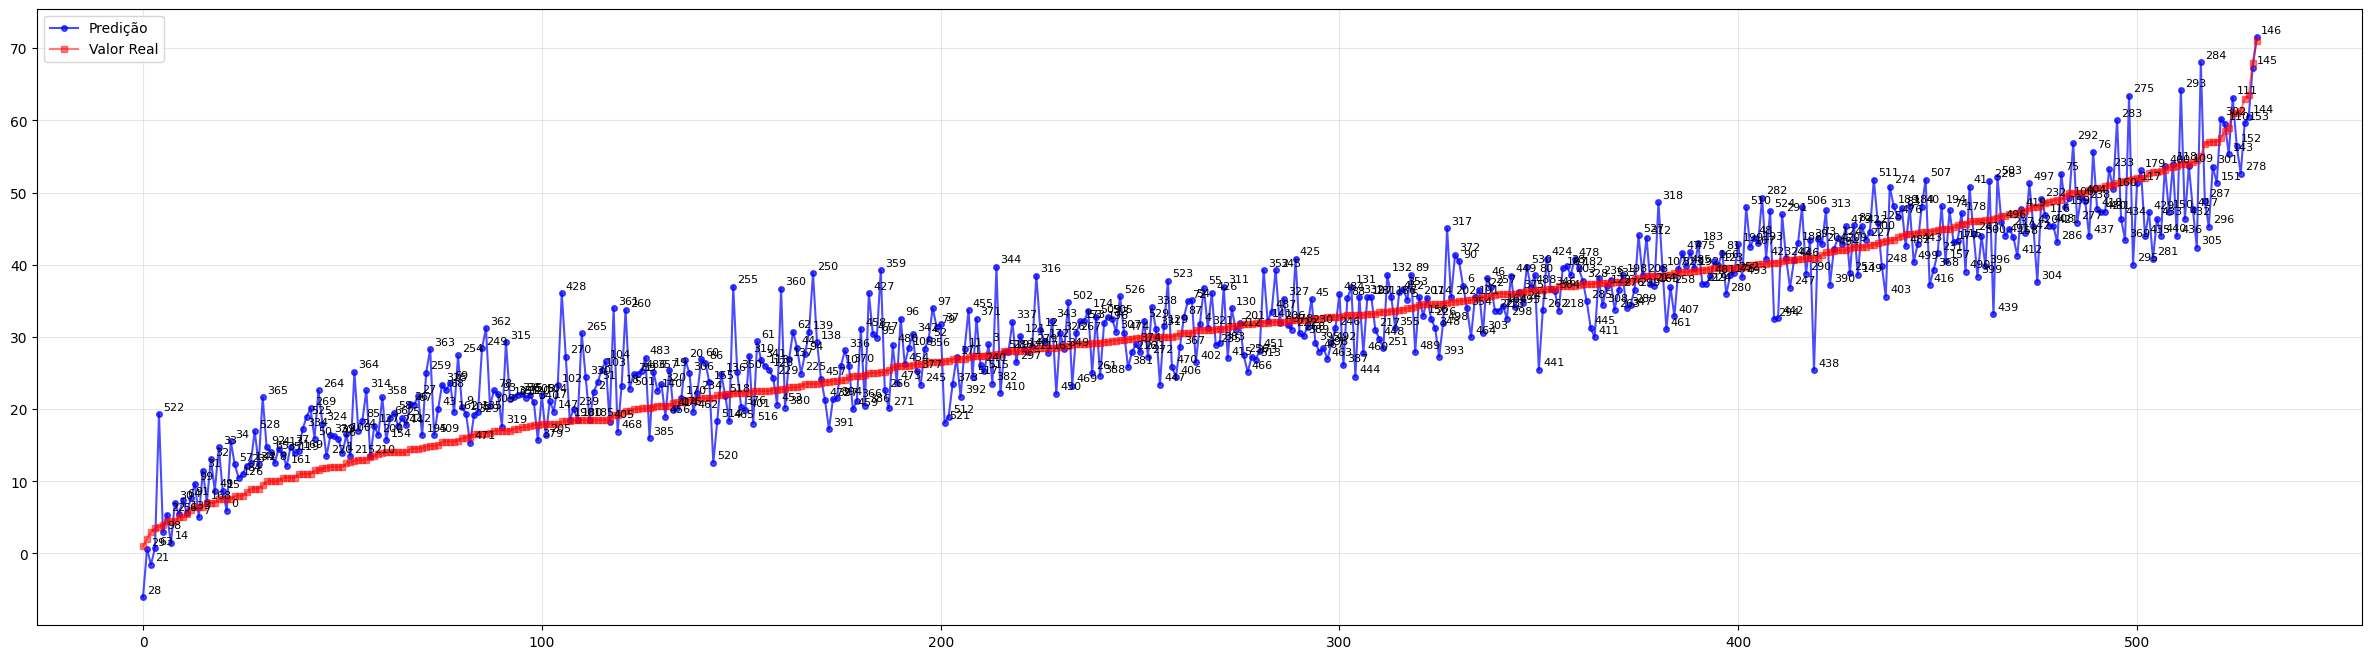

In [219]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

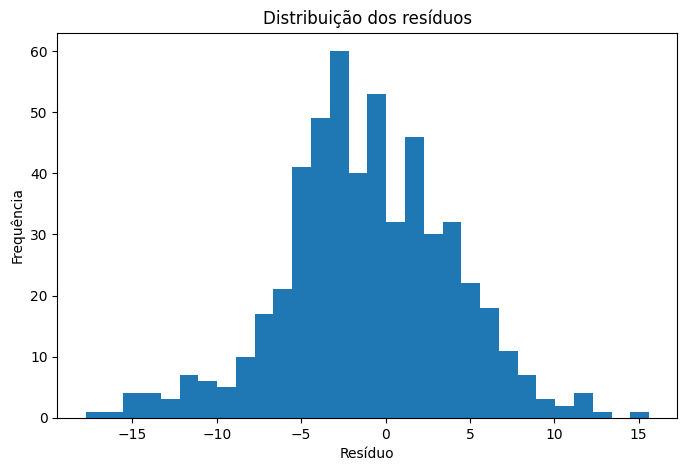

In [220]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

In [221]:
debug_df.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Usa_SP', 'D_Max', 'cod_classe',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Brita_kg_m3', 'vol_brita',
       'porosidade_volumetrica_inicial', 'vol_po_total', 'pasta_agregado',
       'aglomerante_total', 'finos_total', 'range_granulometrico',
       'parametro_feret', 'saturacao_pasta', 'qualidade_adensamento',
       'fator_resistencia_rocha', 'parametro_feret_filer_k5',
       'idade_parametro_feret_filer_k5', 'pow_cubo_vol', 'razao_powers_feret',
       'ryshkewitch_real', 'ryshkewitch_linearizado',
       'hasselman_fator_inicial', 'hasselman_fator_real', 'hasselman_cinetico',
       'schiller_real', 'aci_209_fator_tempo', 's_fib', 'pasta_agregado_fino',
       'densidade_matriz', 'Autores/ano', 'vol_cimento', 'vol_filer',
       'Relacao_Agua_Aglomerante', 'vol_sp', 'target', 'y_true', 'y_pred',
       'error', 'abs_error', 'group', 'residual'],
      dtype='obj

## Residuo vs Predito

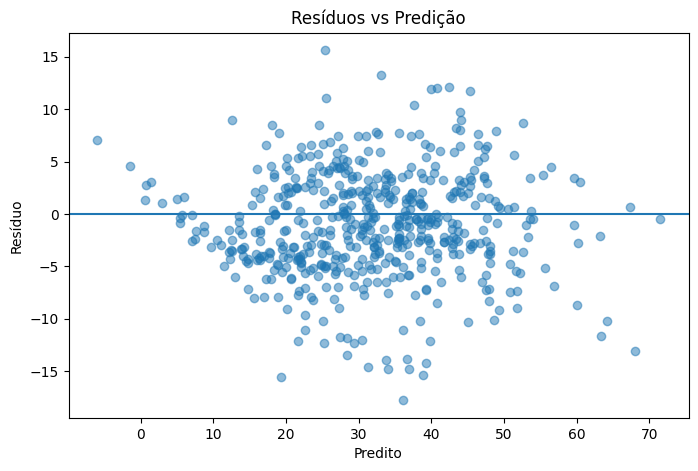

In [222]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()  

## Erro Medio por grupo

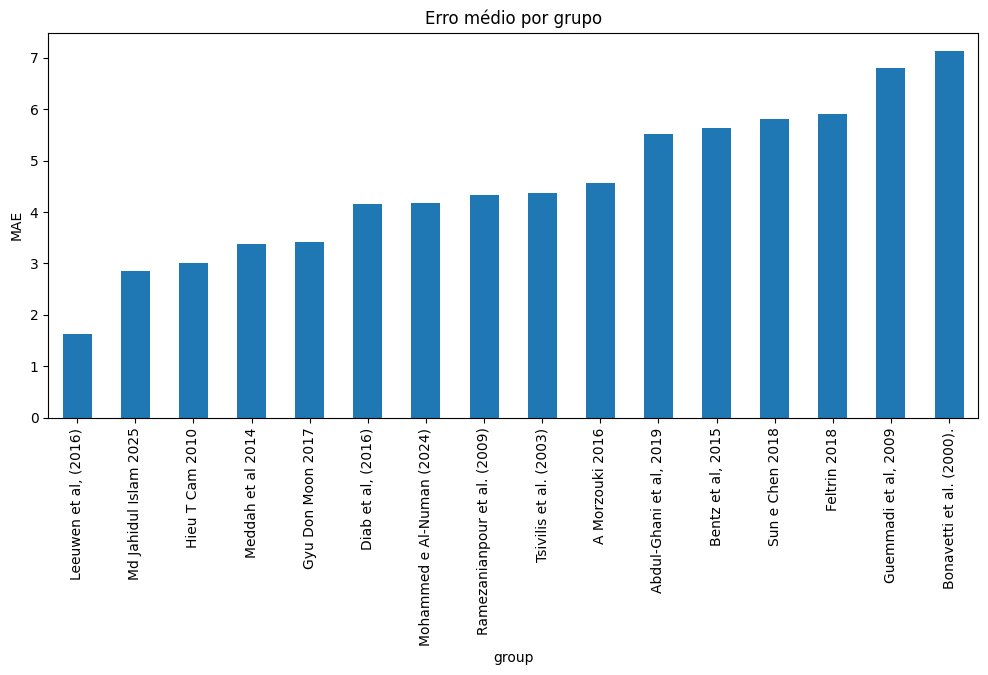

In [223]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

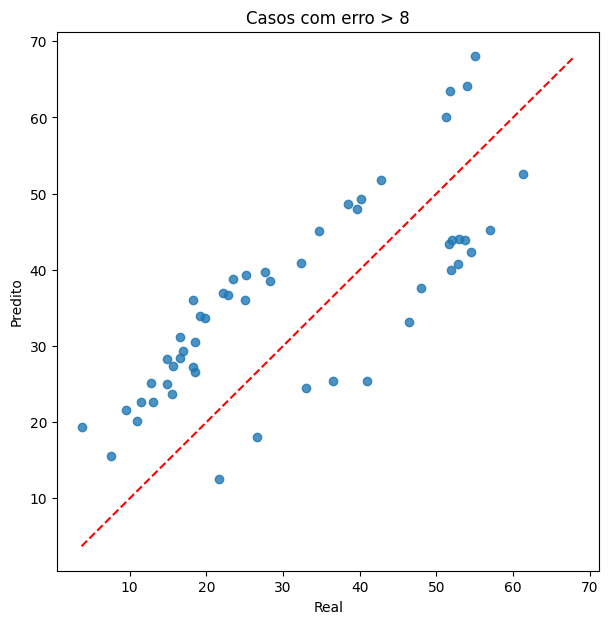

In [224]:
top_erros = (
    debug_df
    .query("abs_error > 8")
    .sort_values("abs_error", ascending=False)
)

plt.figure(figsize=(7,7))

plt.scatter(
    top_erros["y_true"],
    top_erros["y_pred"],
    alpha=0.8
)

mn = min(top_erros["y_true"].min(),
         top_erros["y_pred"].min())

mx = max(top_erros["y_true"].max(),
         top_erros["y_pred"].max())

plt.plot([mn, mx], [mn, mx], 'r--')

plt.xlabel("Real")
plt.ylabel("Predito")
plt.title("Casos com erro > 8")
plt.show()

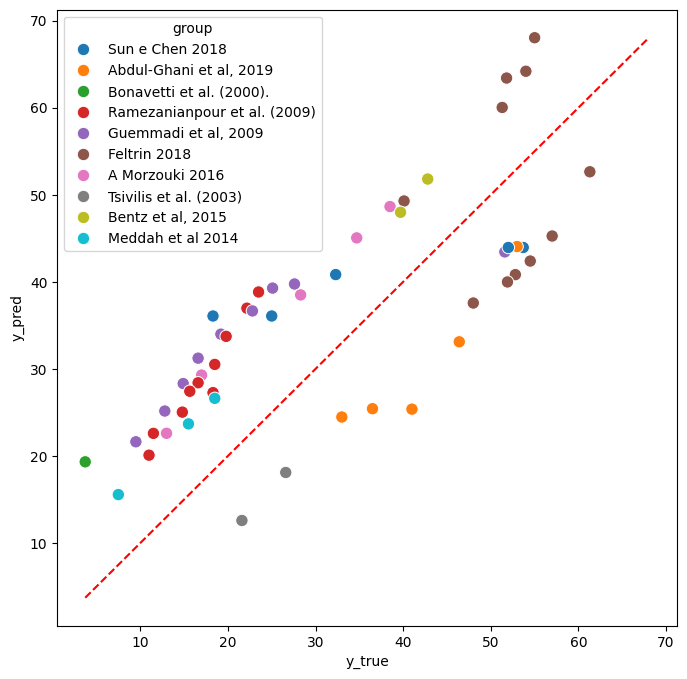

In [225]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=top_erros,
    x="y_true",
    y="y_pred",
    hue="group",
    s=80
)

mn = min(top_erros["y_true"].min(),
         top_erros["y_pred"].min())

mx = max(top_erros["y_true"].max(),
         top_erros["y_pred"].max())

plt.plot([mn,mx],[mn,mx],'r--')
plt.show()

In [226]:
autor_bias = (
    debug_df
    .groupby("group")["residual"]
    .mean()
)

autores_acima = autor_bias[autor_bias > 2].index
autores_abaixo = autor_bias[autor_bias < -2].index

In [227]:
features = [c for c in df_ridge.columns
            if c not in ["target", "Autores/ano"]]

comp = pd.DataFrame({
    "acima": (
        df_ridge[df_ridge["Autores/ano"].isin(autores_acima)]
        [features]
        .mean()
    ),
    "abaixo": (
        df_ridge[df_ridge["Autores/ano"].isin(autores_abaixo)]
        [features]
        .mean()
    )
})

comp["diff"] = comp["acima"] - comp["abaixo"]

comp["abs_diff"] = comp["diff"].abs()

comp.sort_values("abs_diff", ascending=False).head(30)

,acima,abaixo,diff,abs_diff
range_granulometrico,1.577269e+19,1.655198e+19,-7.792842e+17,7.792842e+17
Agregado_Graudo_Total_kg_m3,1.033981e+03,1.180576e+03,-1.465947e+02,1.465947e+02
Cimento_kg_m3,3.103333e+02,2.655185e+02,4.481488e+01,4.481488e+01
Finura_Cimento_Blaine_m2_kg,3.322238e+02,3.744502e+02,-4.222637e+01,4.222637e+01
aglomerante_total,3.626190e+02,3.349812e+02,2.763787e+01,2.763787e+01
Filer_Calcario_kg_m3,5.228571e+01,6.946273e+01,-1.717702e+01,1.717702e+01
Massa_Esp_Cimento_kg_m3,3.126496e+03,3.136264e+03,-9.767816e+00,9.767816e+00
Massa_Esp_Brita_kg_m3,2.618803e+03,2.612359e+03,6.443373e+00,6.443373e+00
cod_classe,9.723810e+00,6.911439e+00,2.812370e+00,2.812370e+00
D_Max,1.834500e+01,2.035055e+01,-2.005549e+00,2.005549e+00


In [228]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 5.1512
mean_absolute_error: 4.0593
mean_absolute_percentage_error: 0.1986
R² Score: 85.0153


## Teste com ElasticNet

In [229]:
X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

def objective(trial):
    rmse_scores = []

    hyperparams = {
        "alpha": trial.suggest_float("alpha", 0.01, 10),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.01, 1.0)
    }
    
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = ElasticNet(**hyperparams, random_state=42)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


In [230]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 100

pbar = tqdm(total=n_trials, desc="Otimizando Regressão ElasticNet")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_elasticnet = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_elasticnet.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_elasticnet.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_elasticnet.best_params.items():
    print(f"  '{key}': {value},")

Otimizando Regressão ElasticNet:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-10 03:36:30,903] A new study created in memory with name: Tuning_Concreto
[I 2026-06-10 03:36:31,084] Trial 0 finished with value: 6.9360822420794985 and parameters: {'alpha': 7.621292880608481, 'l1_ratio': 0.1245176568640531}. Best is trial 0 with value: 6.9360822420794985.
[I 2026-06-10 03:36:31,277] Trial 1 finished with value: 9.136320273765818 and parameters: {'alpha': 9.096140588259125, 'l1_ratio': 0.6942746336884882}. Best is trial 0 with value: 6.9360822420794985.
[I 2026-06-10 03:36:31,437] Trial 2 finished with value: 8.284219723864958 and parameters: {'alpha': 9.40040891430366, 'l1_ratio': 0.3954414464181037}. Best is trial 0 with value: 6.9360822420794985.
[I 2026-06-10 03:36:31,616] Trial 3 finished with value: 4.775609903702616 and parameters: {'alpha': 0.41224669622830834, 'l1_ratio': 0.8941404184670569}. Best is trial 3 with value: 4.775609903702616.
[I 2026-06-10 03:36:31,797] Trial 4 finished with value: 5.344942459222834 and parameters: {'alpha': 1.7756794

Melhor RMSE alcançado (Cross-Validation): 4.6764
Melhores Hiperparâmetros encontrados:
  'alpha': 0.5616250828658143,
  'l1_ratio': 0.031033653832614486,


In [231]:
all_preds = []
all_true = []
all_groups = []

X = df_elasticnet.drop(
    columns=["target", "Autores/ano"]
)

y = df_elasticnet["target"]
groups = df_elasticnet["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = ElasticNet(**study_elasticnet.best_params, random_state=42)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [232]:
elasticnet_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

elasticnet_results["residual"] = (
    elasticnet_results["y_true"] -
    elasticnet_results["y_pred"]
)

elasticnet_results["abs_error"] = (
    elasticnet_results["residual"].abs()
)

## Observado vs Predito

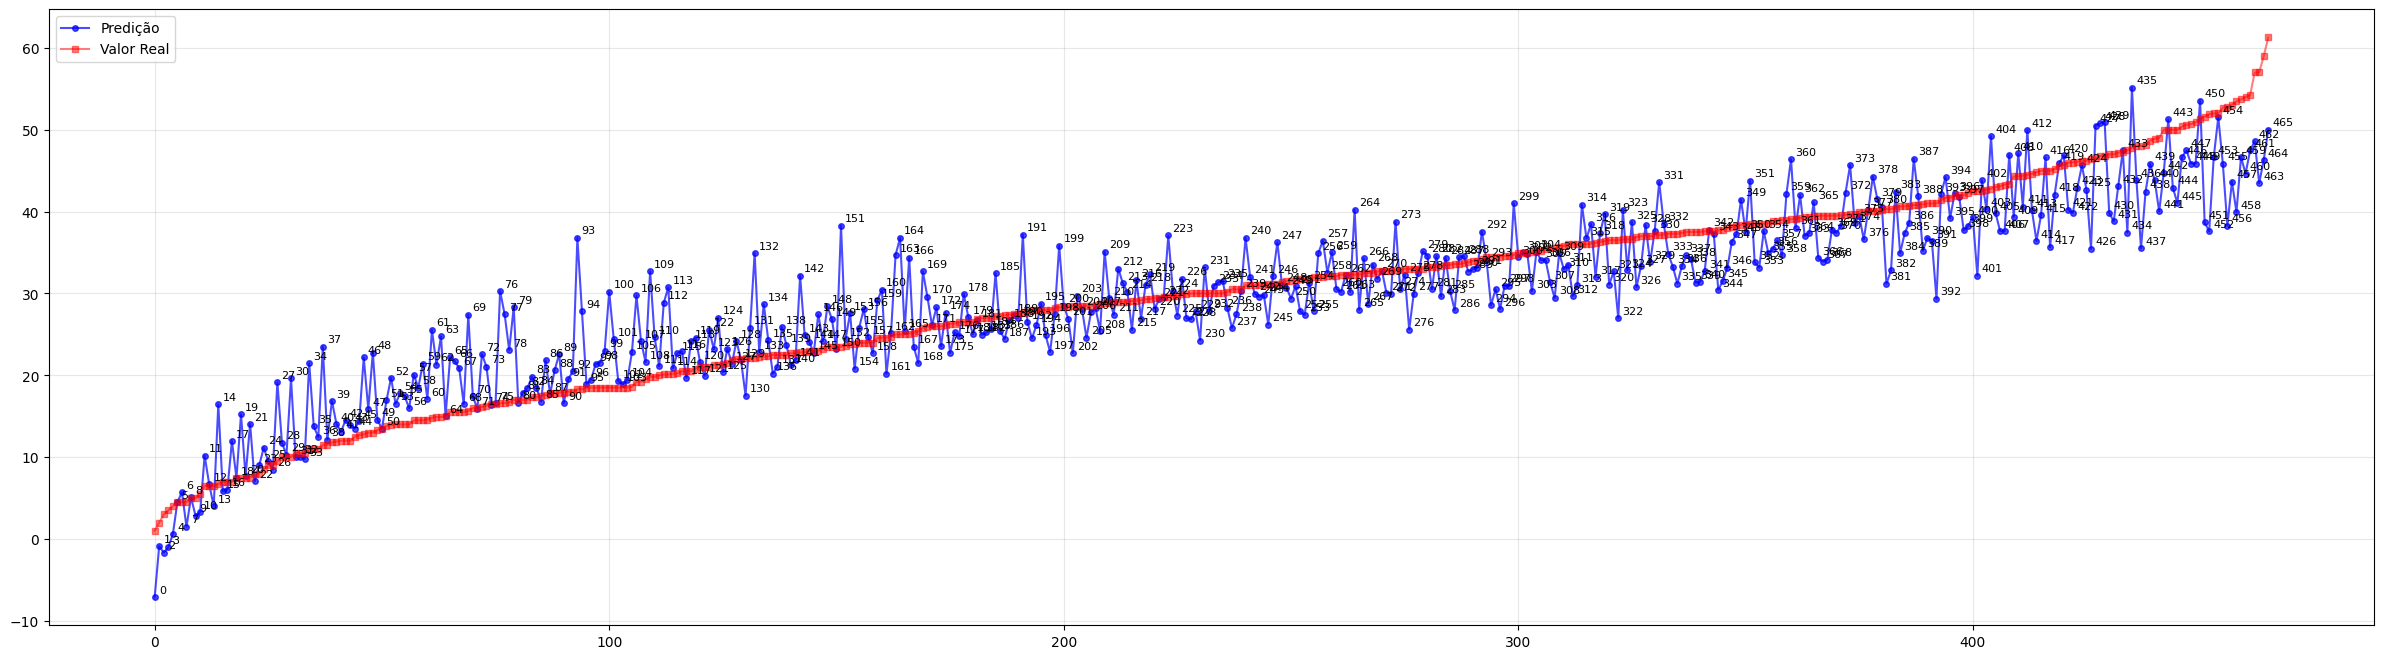

In [233]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = elasticnet_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(30, 8))

plt.plot(
    indices,
    debug_df["y_pred"],
    color='blue',
    label="Predição",
    alpha=0.7,
    linewidth=1.5,
    marker='o',
    markersize=4
)

plt.plot(
    indices,
    debug_df["y_true"],
    color='red',
    label="Valor Real",
    alpha=0.5,
    linewidth=1.5,
    marker='s',
    markersize=4
)

for x, y, idx in zip(
    indices,
    debug_df["y_pred"],
    debug_df.index
):
    plt.annotate(
        str(idx),
        (x, y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=8
    )

plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Distribuição dos residuos

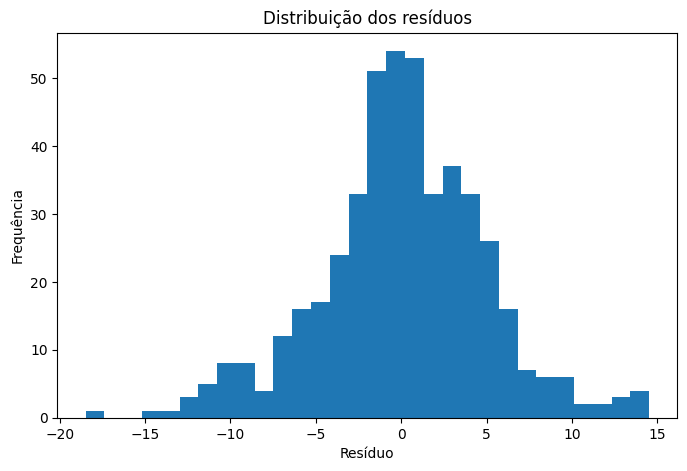

In [234]:
plt.figure(figsize=(8,5))

plt.hist(
    elasticnet_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

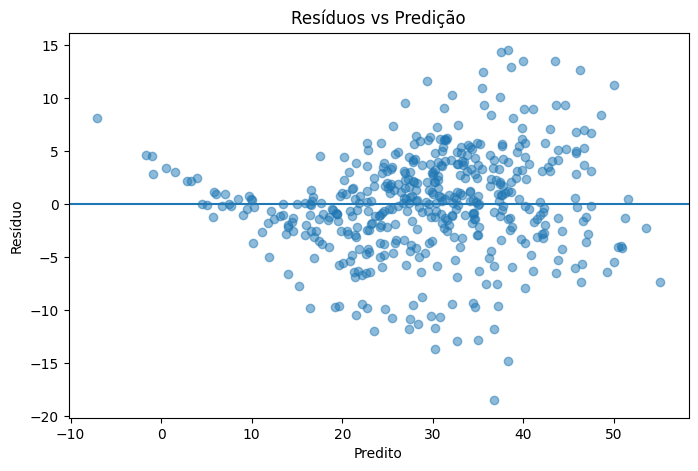

In [235]:
plt.figure(figsize=(8,5))

plt.scatter(
    elasticnet_results["y_pred"],
    elasticnet_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

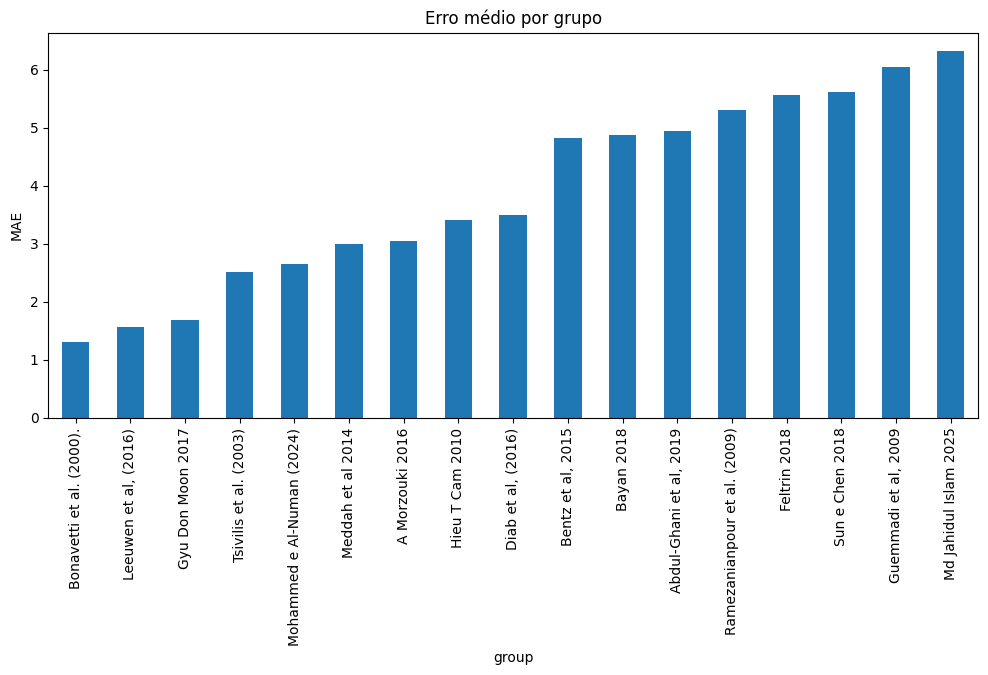

In [236]:
group_errors = (
    elasticnet_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [237]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 4.8898
mean_absolute_error: 3.6756
mean_absolute_percentage_error: 0.1768
R² Score: 83.8336
